# 06 · Event catalogue and clustering

From triggers to a catalogue, and three separate meanings of "clustering":

1. **In time:** are events bunched more than a random (Poisson) process? Inter-event CV, Fano factor, burst sweep.
2. **Across channels:** do two sensors see the same events? Coincidence compared with a time-shifted chance level.
3. **By waveform:** are some events copies of each other (a rattling fitting, a dripping tap)? Cross-correlation
   clustering, plus per-event features (peak frequency, decay time, Q, energy) and feature-space clustering.

Read `docs/STUDENT_GUIDE.md` §7 and §12 first. Triggers are not bubbles, and correlation clusters of *bubbles*
are expected (similar-frequency ringdowns look alike).

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
TAKE = "DEMO_002"
CH = 3                       # channel for the waveform catalogue
BAND = "audio"               # detection band
WINDOW = (50.0, 175.0)       # [s] part of the take to analyse (e.g. after the acid)
MAX_EVENTS = 600             # waveforms to read (random subset if more)
PRE_S, POST_S = 0.002, 0.010 # snippet: 2 ms before to 10 ms after the trigger
RHO_MIN = 0.8                # correlation threshold for waveform clusters
N_FEATURE_CLUSTERS = 3

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
f = za.load_features(cfg, TAKE)
take = za.find_take(za.discover_takes(cfg.data_dir, recursive=cfg.recursive, pattern=cfg.file_pattern), TAKE)
from zoom_acoustics import catalogue as K
ev = f.events
ev = ev[(ev.band == BAND) & (ev.t_s >= WINDOW[0]) & (ev.t_s < WINDOW[1])]
ev = ev[~za.masks.mask_array(ev.t_s.to_numpy(), f.mask_windows)]
ev.groupby("channel").size().rename("triggers in window")

channel
1    2584
2    2428
3     558
Name: triggers in window, dtype: int64

## 1. Clustering in time

CV = 1 and Fano = 1 for a Poisson process. Gaps that straddle a masked window are removed (they are holes
cut by the mask, not intervals). A burst count is meaningful only if it has a **plateau** over a range of gap values.

In [4]:
rows = []
for c in f.channels:
    t = ev[ev.channel == c].t_s.to_numpy()
    st = K.interevent_stats(t, windows=f.mask_windows, dead_s=f.meta["detector"]["dead_s"], t_range=WINDOW)
    rows.append(dict(channel=c, label=f.label(c), **{k: v for k, v in st.items()}))
pd.DataFrame(rows).round(3)

,channel,label,n,reportable,n_gaps,n_gaps_removed_straddling_mask,mean_gap_s,cv,ks_D,ks_p,frac_gaps_below_2x_dead,fano_1s
0,1,Ch1 Hydrophone A,2584,True,2571.0,12.0,0.040,0.875,0.045,0.000,0.029,0.665
1,2,Ch2 Hydrophone B,2428,True,2415.0,12.0,0.043,0.863,0.049,0.000,0.027,0.716
2,3,Ch3 Contact sensor,558,True,545.0,12.0,0.181,0.904,0.052,0.102,0.000,0.635
3,4,Ch4 Air mic,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,gap_s,n_bursts
0,0.05,439
1,0.10,331
2,0.20,180
3,0.50,31
4,1.00,1
5,2.00,1
6,5.00,1


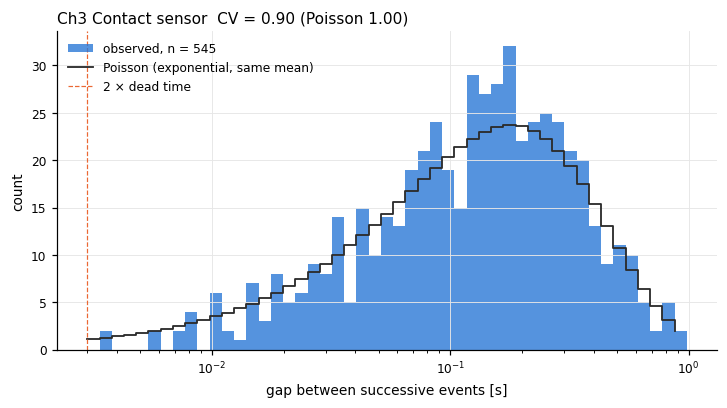

In [5]:
t = ev[ev.channel == CH].t_s.to_numpy()
fig = zp.plot_interevent(t, f.mask_windows, f.meta["detector"]["dead_s"], title=f"{f.label(CH)}")
zp.save(fig, cfg, f"{TAKE}_interevent_ch{CH}")
K.burst_sweep(t, windows=f.mask_windows)

## 2. Coincidence between channels

For each pair: the fraction of A's events with a B event within ±3 ms, compared with the same after shifting B by
several seconds (chance). Only the **excess** means anything. The lag is B minus A. A constant lag of a fraction of
a millisecond between two sensors a few cm apart is mostly instrument group delay, not travel time.

In [6]:
rows = []
for a in f.channels:
    for b in f.channels:
        if a < b:
            r = K.coincidence(ev[ev.channel == a].t_s, ev[ev.channel == b].t_s, win_s=3e-3)
            rows.append(dict(A=a, B=b, **{k: v for k, v in r.items() if k != "lags_s"}))
pd.DataFrame(rows).round(3)

,A,B,n_a,n_b,reportable,win_s,frac_obs,frac_chance,excess,lag_median_ms
0,1,2,2584,2428,True,0.003,0.923,0.097,0.915,0.5
1,1,3,2584,558,True,0.003,0.224,0.024,0.205,0.5
2,1,4,2584,0,False,NaN,NaN,NaN,NaN,NaN
3,2,3,2428,558,True,0.003,0.238,0.025,0.219,0.0
4,2,4,2428,0,False,NaN,NaN,NaN,NaN,NaN
5,3,4,558,0,False,NaN,NaN,NaN,NaN,NaN


## 3. Waveforms, features and waveform clusters

Snippets are read from the WAV files (not the cache). Features per event: peak amplitude, energy, rise and decay
time, peak and centroid frequency, bandwidth, Q = π f τ, and the level of the second spectral peak.

In [7]:
W, tt, sr = K.extract_waveforms(take, ev[ev.channel == CH].t_s, CH, PRE_S, POST_S, max_events=MAX_EVENTS)
feat_df = K.waveform_features(W, sr, PRE_S)
feat_df.insert(0, "t_s", tt)
feat_df.describe().round(3)

,t_s,peak_amp,energy,rise_ms,decay_ms,f_peak_hz,f_centroid_hz,bandwidth_hz,q_est,peak2_rel_db,snr_db
count,558.000,558.000,558.0,558.000,557.000,558.000,558.000,558.000,557.000,558.000,558.000
mean,108.658,0.006,0.0,0.144,0.657,5768.070,6290.605,3461.391,11.812,-10.688,18.154
std,36.839,0.013,0.0,0.091,0.359,948.102,1133.165,428.417,6.416,4.475,7.137
min,50.203,0.001,0.0,0.042,0.103,1500.000,2746.855,2208.745,1.810,-19.578,10.568
25%,74.676,0.002,0.0,0.104,0.371,5583.333,5847.000,3292.610,6.484,-14.358,14.790
50%,109.504,0.002,0.0,0.125,0.623,5583.333,6224.088,3528.582,10.842,-10.933,16.350
75%,139.904,0.003,0.0,0.146,0.886,5583.333,6503.283,3746.878,16.863,-7.440,18.222
max,173.655,0.054,0.0,0.812,2.755,9000.000,10105.788,4459.520,48.316,-0.003,45.822


In [8]:
C = K.xcorr_matrix(W)
lab, clusters, med = K.cluster_waveforms(C, rho_min=RHO_MIN, features=feat_df, times=tt)
print(f"median pairwise correlation of all events: {med:.2f}")
clusters.head(10).round(2)

median pairwise correlation of all events: 0.51


,cluster,size,median_rho,f_peak_hz,peak2_rel_db,null_rho,gap_cv
0,1,37,0.94,9000.00,-4.65,NaN,0.34
1,25,4,0.86,5583.33,-5.61,0.47,1.04
2,36,6,0.86,5583.33,-2.62,0.41,0.87
3,41,3,0.85,5583.33,-6.06,0.47,1.00
4,164,3,0.85,5583.33,-9.28,0.53,1.17
5,50,3,0.85,5583.33,-6.70,0.50,1.38
6,45,9,0.85,5583.33,-7.37,0.49,1.11
7,198,3,0.85,5583.33,-13.94,0.46,0.93
8,6,3,0.85,5583.33,-5.18,0.40,0.59
9,26,3,0.85,5583.33,-8.79,0.51,0.88


**How to read this table.** Clusters are ranked by internal similarity (`median_rho`). A repeating mechanical
source stands out only if it is clearly *more* similar than the rest. Check `f_peak_hz`: a cluster on an apparatus
line (5.6 kHz in the Sep-2026 rig) is the line. `gap_cv` well below 1 means regular timing. Then **look at the
gallery.**

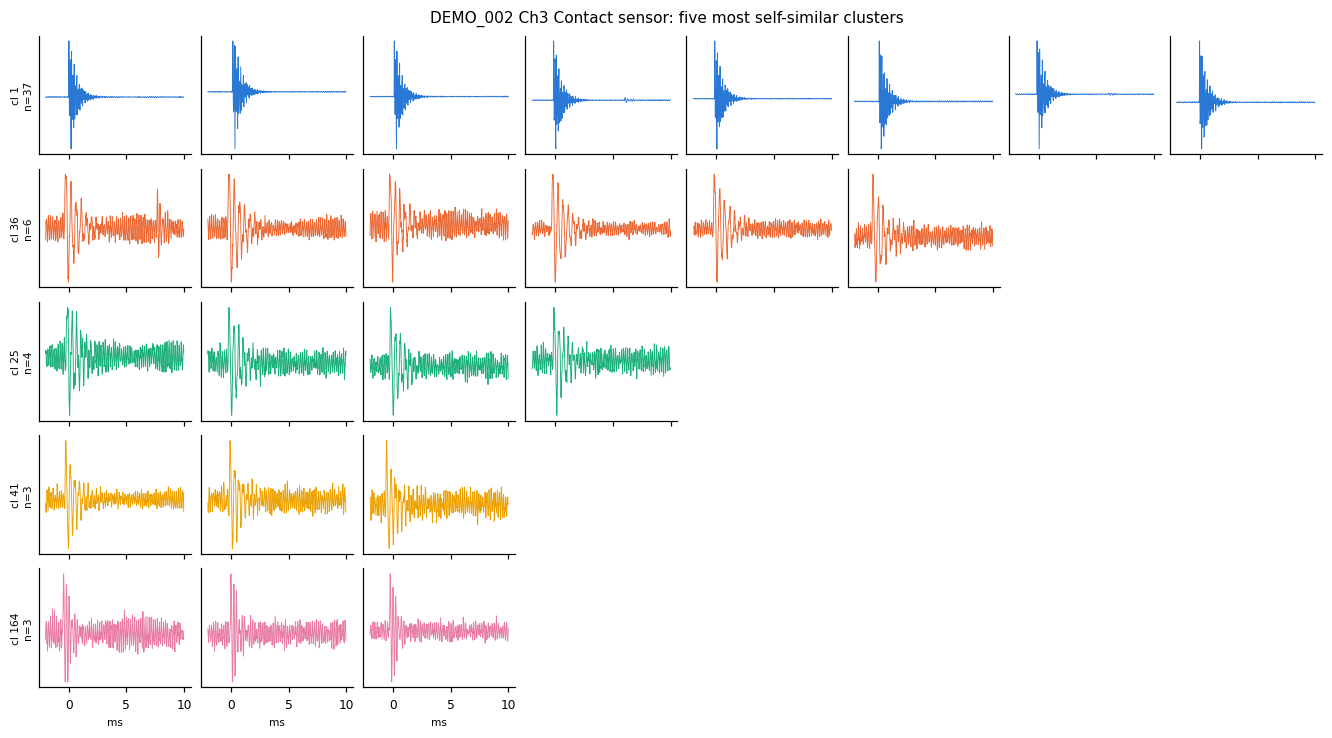

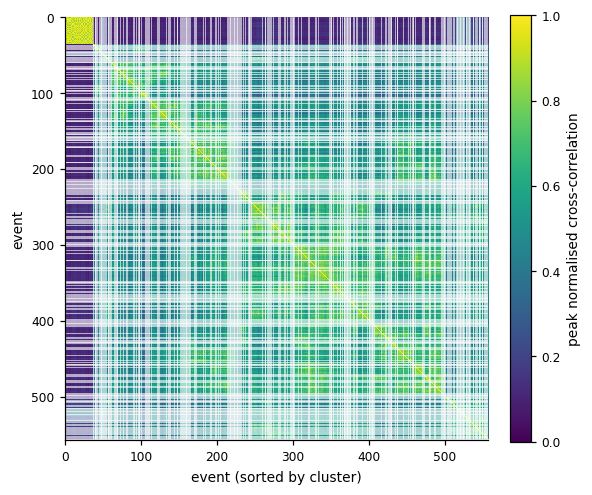

In [9]:
top = clusters.cluster.head(5).tolist()
lab_show = np.where(np.isin(lab, top), lab, 0)
fig = zp.plot_waveform_gallery(W[lab_show > 0], sr, lab_show[lab_show > 0], pre_s=PRE_S,
                               title=f"{TAKE} {f.label(CH)}: five most self-similar clusters")
zp.save(fig, cfg, f"{TAKE}_gallery_ch{CH}")
fig = zp.plot_corr_matrix(C, lab)

### Feature-space clustering (descriptive)

Ward clustering of standardised log-features. **k is your choice**, so re-run with other k and other feature
sets, and only trust groups that persist.

,f_peak_hz,decay_ms,q_est,energy
cluster,,,,
0,5583.3333,NaN,NaN,0.0
1,9000.0000,0.6397,18.0860,0.0
2,5583.3333,0.3536,6.2016,0.0
3,5583.3333,0.8904,15.5349,0.0


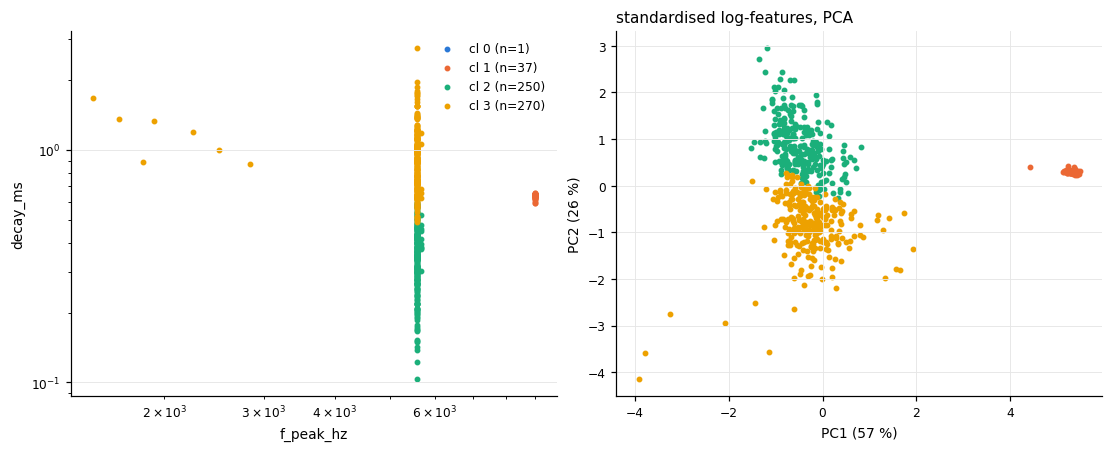

In [10]:
flab, scores, evr = K.feature_clusters(feat_df, n_clusters=N_FEATURE_CLUSTERS)
fig = zp.plot_feature_space(feat_df, flab, scores, evr)
zp.save(fig, cfg, f"{TAKE}_features_ch{CH}")
feat_df.assign(cluster=flab).groupby("cluster")[["f_peak_hz", "decay_ms", "q_est", "energy"]].median().round(4)

In [11]:
out = feat_df.assign(xcorr_cluster=lab, feature_cluster=flab, channel=CH, take=TAKE)
out.to_csv(cfg.figures_path / f"{TAKE}_catalogue_ch{CH}.csv", index=False)
print("wrote", cfg.figures_path / f"{TAKE}_catalogue_ch{CH}.csv", len(out), "events")

wrote /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_catalogue_ch3.csv 558 events
